# 05 - Flipped Experiment: Train Rural, Test Urban

Reverses the distribution shift experiment from notebook 04.
Trains on rural data and evaluates on urban to test whether the shift is symmetric.

| Dataset | Rows | Fatal | Fatality rate | Role |
|---|---|---|---|---|
| Rural (speed < 90) | 1,421 | 70 | 4.93% | Train |
| Urban | 3,544 | 64 | 1.81% | Test |

**Steps**
1. Feature engineering helper
2. Load & engineer rural training set
3. Load & engineer urban test set
4. Train Logistic Regression on rural
5. Evaluate on urban
6. Compare both directions
7. ROC & PR curves

**Key question:** does training on rural data transfer better to urban than the reverse?
An asymmetric result would suggest the two contexts differ in which direction signal generalises.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42

### 1. Feature Engineering Helper

Identical transformations to notebooks 02 and 04.
`settlement` excluded from OHE in both sets for consistency --
rural has 549 unique values, urban has 22, neither transfers meaningfully to the other.

In [2]:
def engineer_features(df_raw):
    df = df_raw.copy()

    # Target
    df['is_fatal'] = (df['deaths'].fillna(0) > 0).astype(int)

    # Speed limit remap
    df['speed_limit'] = df['speed_limit'].replace(
        {5: 20, 10: 20, 15: 20, 25: 30, 45: 40, 60: 70, 80: 70}
    )

    # Road width bin
    df['road_width_bin'] = pd.cut(
        df['road_width'],
        bins=[0, 5, 9, 14, np.inf],
        labels=['narrow', 'standard', 'wide', 'arterial'],
        right=True
    )

    # Temporal features
    df['accident_time'] = pd.to_datetime(df['accident_time'])
    hour = df['accident_time'].dt.hour
    dow  = df['accident_time'].dt.dayofweek

    def assign_hour_bin(h):
        if h in range(22, 24) or h in range(0, 6):           return 'night'
        elif h in list(range(7, 10)) + list(range(15, 19)):  return 'rush'
        elif h in range(19, 22):                              return 'evening'
        else:                                                 return 'day'

    df['hour_bin']   = hour.map(assign_hour_bin)
    df['is_weekend'] = (dow >= 5).astype(int)

    # OHE -- settlement excluded in both directions
    OHE_COLS = [
        'accident_type', 'accident_type_detailed', 'road_condition',
        'lighting', 'road_width_bin', 'hour_bin', 'weather',
    ]
    df = pd.get_dummies(df, columns=[c for c in OHE_COLS if c in df.columns],
                        drop_first=False, dtype=int)

    DROP_COLS = [
        'deaths', 'injured',
        'road_type_detailed', 'road_surface_condition',
        'accident_scenario', 'join_distance',
        'road_type', 'road_width',
        'x_coord', 'y_coord',
        'accident_id', 'accident_time',
        'county', 'municipality', 'settlement',
        'involving_motorvehicle_driver',
    ]
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

    return df


def align_columns(df, train_cols):
    """
    Align test set columns to training feature space.
    - Missing columns (unseen in test): add as zeros
    - Extra columns (not in train): drop
    """
    missing = set(train_cols) - set(df.columns)
    extra   = set(df.columns) - set(train_cols) - {'is_fatal'}
    for col in missing:
        df[col] = 0
    df = df.drop(columns=list(extra), errors='ignore')
    df = df[train_cols + ['is_fatal']]
    if missing: print(f'  Added {len(missing)} missing columns as zeros')
    if extra:   print(f'  Dropped {len(extra)} unseen columns')
    return df


print('Helper functions defined.')

Helper functions defined.


## 2. Load & Engineer Rural Training Set

In [4]:
# -- Data paths -- update to your local environment
DATA_DIR  = '../data/'
rural_raw = pd.read_csv(DATA_DIR + 'rural_filter.csv')

print(f'Rural raw: {len(rural_raw):,} rows')

rural = engineer_features(rural_raw)

X_train    = rural.drop(columns=['is_fatal'])
y_train    = rural['is_fatal']
TRAIN_COLS = X_train.columns.tolist()

print(f'After engineering: {X_train.shape[1]} features')
print(f'Fatal: {y_train.sum()} ({y_train.mean()*100:.2f}%)')
print(f'Imbalance ratio: {(y_train==0).sum() / (y_train==1).sum():.1f}:1')

Rural raw: 1,421 rows
After engineering: 50 features
Fatal: 70 (4.93%)
Imbalance ratio: 19.3:1


## 3. Load & Engineer Urban Test Set

In [6]:
# -- Data paths -- update to your local environment
urban_raw = pd.read_csv(DATA_DIR + 'urban_filter.csv')

print(f'Urban raw: {len(urban_raw):,} rows')

urban = engineer_features(urban_raw)
urban = align_columns(urban, TRAIN_COLS)

X_test = urban[TRAIN_COLS]
y_test = urban['is_fatal']

print(f'After engineering & alignment: {X_test.shape[1]} features')
print(f'Fatal: {y_test.sum()} ({y_test.mean()*100:.2f}%)')

Urban raw: 3,544 rows
  Added 2 missing columns as zeros
  Dropped 13 unseen columns
After engineering & alignment: 50 features
Fatal: 64 (1.81%)


## 4. Train Logistic Regression on Rural

In [7]:
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr.fit(X_train_sc, y_train)

print('Logistic Regression trained on rural data.')
print(f'Train: {len(y_train):,} rows  |  fatal: {y_train.sum()} ({y_train.mean()*100:.2f}%)')

Logistic Regression trained on rural data.
Train: 1,421 rows  |  fatal: 70 (4.93%)


## 5. Evaluate on Urban Test Set

In [8]:
preds = lr.predict(X_test_sc)
proba = lr.predict_proba(X_test_sc)[:, 1]

roc = roc_auc_score(y_test, proba)
pr  = average_precision_score(y_test, proba)

print('=== Rural -> Urban (Flipped Experiment) ===')
print(f'ROC-AUC: {roc:.4f}   PR-AUC: {pr:.4f}')
print()
print(classification_report(y_test, preds, target_names=['non-fatal', 'fatal'], digits=3))

cm = confusion_matrix(y_test, preds)
print('Confusion matrix:')
print(cm)
print('  [TN  FP]')
print('  [FN  TP]')

=== Rural -> Urban (Flipped Experiment) ===
ROC-AUC: 0.7325   PR-AUC: 0.0485

              precision    recall  f1-score   support

   non-fatal      0.991     0.739     0.847      3480
       fatal      0.043     0.641     0.081        64

    accuracy                          0.737      3544
   macro avg      0.517     0.690     0.464      3544
weighted avg      0.974     0.737     0.833      3544

Confusion matrix:
[[2572  908]
 [  23   41]]
  [TN  FP]
  [FN  TP]


In [9]:
# Probability distribution check
print('Predicted probabilities for FATAL cases:')
print(pd.Series(proba[y_test == 1]).describe().round(4))
print('\nPredicted probabilities for NON-FATAL cases:')
print(pd.Series(proba[y_test == 0]).describe().round(4))

sep = proba[y_test == 1].mean() - proba[y_test == 0].mean()
print(f'\nSeparation: {sep:.4f}')

Predicted probabilities for FATAL cases:
count   64.0000
mean     0.5476
std      0.2452
min      0.0091
25%      0.4342
50%      0.5624
75%      0.7436
max      0.9586
dtype: float64

Predicted probabilities for NON-FATAL cases:
count   3480.0000
mean       0.3378
std        0.2516
min        0.0000
25%        0.1430
50%        0.3006
75%        0.5148
max        0.9724
dtype: float64

Separation: 0.2098


## 6. Compare Both Directions

In [13]:
# Original direction results from notebook 04 -- update after running
tn, fp, fn, tp = cm.ravel()
recall = tp / (tp + fn)

print(f'{"Direction":<30} {"Train fatal":>12} {"Test fatal":>10} {"ROC-AUC":>8} {"PR-AUC":>8} {"Recall":>8} {"TP":>6} {"FN":>6}')
print('-' * 95)
print(f'{"Urban -> Rural (original)":<30} {64:>12} {70:>10} {0.6350:>8.4f} {0.1007:>8.4f} {0.500:>8.3f} {35:>6} {35:>6}')
print(f'{"Rural -> Urban (flipped)":<30} {70:>12} {64:>10} {roc:>8.4f} {pr:>8.4f} {recall:>8.3f} {tp:>6} {fn:>6}')
print()
print(f'ROC-AUC difference (flipped - original): {roc - 0.6333:+.4f}')

Direction                       Train fatal Test fatal  ROC-AUC   PR-AUC   Recall     TP     FN
-----------------------------------------------------------------------------------------------
Urban -> Rural (original)                64         70   0.6350   0.1007    0.500     35     35
Rural -> Urban (flipped)                 70         64   0.7325   0.0485    0.641     41     23

ROC-AUC difference (flipped - original): +0.0992


## 7. ROC & PR Curves

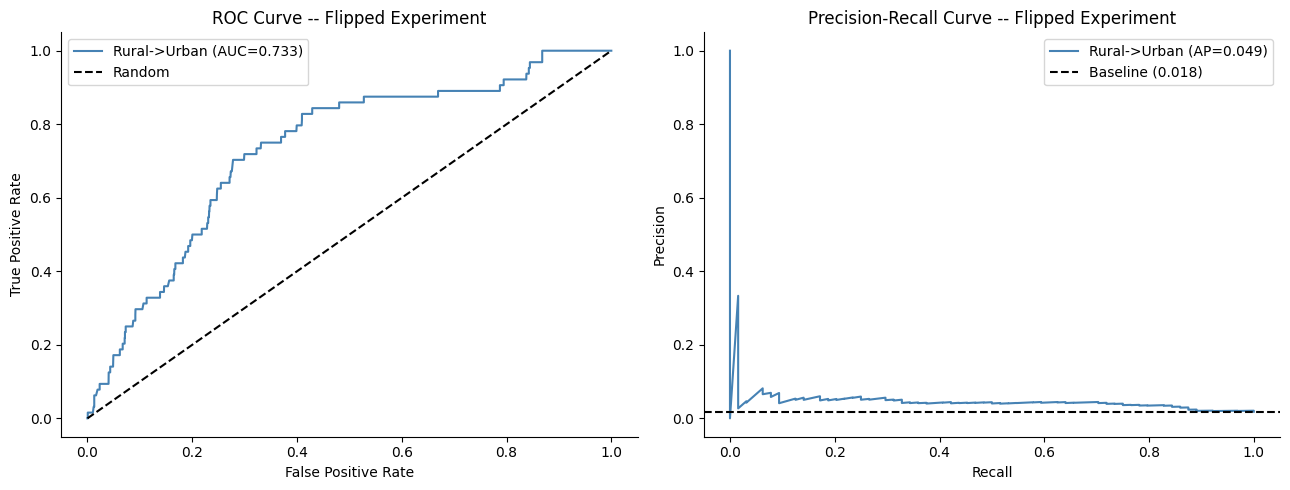

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr_vals, tpr_vals, _ = roc_curve(y_test, proba)
axes[0].plot(fpr_vals, tpr_vals, color='steelblue', label=f'Rural->Urban (AUC={roc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve -- Flipped Experiment')
axes[0].legend()
sns.despine(ax=axes[0])

prec_vals, rec_vals, _ = precision_recall_curve(y_test, proba)
axes[1].plot(rec_vals, prec_vals, color='steelblue', label=f'Rural->Urban (AP={pr:.3f})')
axes[1].axhline(y_test.mean(), color='k', linestyle='--',
                label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve -- Flipped Experiment')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('flipped_roc_pr.png', dpi=150)
plt.show()

---

## Summary

| Direction | Train fatal | Test fatal | ROC-AUC | PR-AUC | Recall | TP | FN |
|---|---|---|---|---|---|---|---|
| Urban -> Rural | 64 | 70 | 0.6350| 0.1007 | 0.500 | 35 | 35 |
| Rural -> Urban | 70 | 64 | 0.7325 | 0.0485 | 0.641 | 41 | 23 |

**Interpretation:**
- Higher flipped ROC-AUC suggests rural features generalise better to urban than the reverse
- Lower flipped recall despite higher AUC indicates the probability scale shifts across contexts --
  the model ranks well but the default threshold misses most urban fatal cases
- The asymmetry confirms the two contexts differ in ways that favour one training direction

**Next -> `06_national_baseline.ipynb`:** train on the full national dataset to establish the performance ceiling.